# 건물 존재 여부 기반 100m 격자 필터링

기존에 만든 대구·경북 10개 시·군·구(17개 행정경계) 100m 격자(`data/grid_100m_daegugyeongbuk`, 676,339개) 중,
[V-World GIS건물일반공간정보](https://www.vworld.kr/dtmk/dtmk_ntads_s002.do?svcCde=NA&dsId=5)의 건물 폴리곤과 **교차하는 격자만** 추출해 접근성 계산에 쓸 최종 격자를 만든다.

- 원본: 대구광역시(`AL_D010_27_*`, 군위군 포함) + 경상북도(`AL_D010_47_*`, 3개 파일로 분할) — `data/raw_vworld_buildings/`에 위치 (용량이 커서 git에는 커밋하지 않음, `.gitignore` 처리)
- 좌표계: 건물 데이터는 EPSG:5186(중부원점) — 시군구 경계와 동일, 격자는 EPSG:5179이므로 결합 시 변환 필요
- 건물 속성(용도·연면적 등)은 필요 없고 "건물이 존재하는지"만 판단하므로, 읽을 때부터 속성 컬럼 없이 geometry만 로드해 처리 속도를 높인다

In [1]:
import glob
import zipfile
import time

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"  # 한글 라벨 표시를 위한 폰트 설정
plt.rcParams["axes.unicode_minus"] = False

## 1. 원본 zip 압축 해제

`AL_D010_27_*.zip`(대구), `AL_D010_47_*.zip`(경북)을 `data/raw_vworld_buildings/`에 풀어둔다.

In [2]:
RAW_DIR = "data/raw_vworld_buildings"

zip_paths = glob.glob(f"{RAW_DIR}/AL_D010_27_*.zip") + glob.glob(f"{RAW_DIR}/AL_D010_47_*.zip")
assert len(zip_paths) == 2, f"대구(27)·경북(47) zip 파일 2개가 {RAW_DIR}에 있어야 합니다: {zip_paths}"

for zp in zip_paths:
    with zipfile.ZipFile(zp) as z:
        z.extractall(RAW_DIR)
    print("압축 해제:", zp)

daegu_shp = glob.glob(f"{RAW_DIR}/AL_D010_27_*.shp")
gb_shps = sorted(glob.glob(f"{RAW_DIR}/AL_D010_47_*.shp"))
print("대구 건물 파일:", daegu_shp)
print("경북 건물 파일:", gb_shps)

압축 해제: data/raw_vworld_buildings/AL_D010_27_20260809.zip


압축 해제: data/raw_vworld_buildings/AL_D010_47_20260809.zip
대구 건물 파일: ['data/raw_vworld_buildings/AL_D010_27_20260809.shp']
경북 건물 파일: ['data/raw_vworld_buildings/AL_D010_47_20260809(2).shp', 'data/raw_vworld_buildings/AL_D010_47_20260809(3).shp', 'data/raw_vworld_buildings/AL_D010_47_20260809.shp']


## 2. 대상 시군구 경계 로드

`load_data.ipynb`(DaeguGyeongbuk_accessibility)와 동일한 17개 행정경계(대구 9개 구·군 + 구미·김천·영천·경산·청도·고령·성주·칠곡)를 사용한다.

In [3]:
sigungu = gpd.read_file("data/BND_SIGUNGU_PG/BND_SIGUNGU_PG.shp", encoding="cp949")

target_codes = [
    "22010", "22020", "22030", "22040", "22050", "22060", "22070", "22510", "22520",  # 대구
    "37050", "37030", "37070", "37100",  # 구미, 김천, 영천, 경산
    "37560", "37570", "37580", "37590",  # 청도, 고령, 성주, 칠곡
]
target_sigungu = sigungu[sigungu["SIGUNGU_CD"].isin(target_codes)].copy()
target_union = target_sigungu.union_all()
bounds = tuple(target_sigungu.total_bounds)  # 건물 데이터와 같은 EPSG:5186

print(f"대상 시군구: {len(target_sigungu)}개 폴리곤, CRS={target_sigungu.crs}")

대상 시군구: 17개 폴리곤, CRS=EPSG:5186


## 3. 건물 폴리곤 로드 (속성 없이 geometry만, bbox로 1차 필터)

전국/도 단위 원본은 수십만~수백만 건이라, 읽는 시점에 대상 지역 bbox로 걸러서 불필요한 로드를 피한다. 이후 bbox보다 좁은 실제 시군구 경계(`target_union`)로 정밀하게 한 번 더 자른다.

In [4]:
t0 = time.time()

parts = []
for shp in daegu_shp + gb_shps:
    g = gpd.read_file(shp, bbox=bounds, columns=[], encoding="cp949")
    parts.append(g)
    print(f"{shp}: {len(g)}개 (bbox 필터)")

buildings = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs="EPSG:5186")
print(f"bbox 필터 후 합계: {len(buildings)}개, {time.time()-t0:.1f}초")

buildings = buildings[buildings.intersects(target_union)].copy()
print(f"시군구 경계 정밀 필터 후: {len(buildings)}개, {time.time()-t0:.1f}초")

buildings_5179 = buildings.to_crs("EPSG:5179")

data/raw_vworld_buildings/AL_D010_27_20260809.shp: 382697개 (bbox 필터)


data/raw_vworld_buildings/AL_D010_47_20260809(2).shp: 446753개 (bbox 필터)
data/raw_vworld_buildings/AL_D010_47_20260809(3).shp: 4335개 (bbox 필터)


data/raw_vworld_buildings/AL_D010_47_20260809.shp: 393039개 (bbox 필터)
bbox 필터 후 합계: 1226824개, 2.6초


시군구 경계 정밀 필터 후: 1063843개, 33.3초


## 4. 100m 격자와 공간 조인 — 건물과 교차하는 격자만 추출

In [5]:
grid = gpd.read_file("data/grid_100m_daegugyeongbuk/grid_100m_daegugyeongbuk.shp", encoding="cp949")
print(f"기존 100m 격자: {len(grid)}개")

joined = gpd.sjoin(grid, buildings_5179, how="inner", predicate="intersects")
grid_with_buildings = grid.loc[joined.index.unique()].copy()

print(f"건물과 교차하는 격자: {len(grid_with_buildings)}개 "
      f"({len(grid_with_buildings)/len(grid)*100:.1f}%)")

기존 100m 격자: 676339개


건물과 교차하는 격자: 144528개 (21.4%)


## 5. 결과 저장

In [6]:
import os

out_dir = "data/grid_100m_daegugyeongbuk_with_buildings"
os.makedirs(out_dir, exist_ok=True)
out_path = f"{out_dir}/grid_100m_daegugyeongbuk_with_buildings.shp"
grid_with_buildings.to_file(out_path, encoding="cp949")
print("저장 완료:", out_path)

저장 완료: data/grid_100m_daegugyeongbuk_with_buildings/grid_100m_daegugyeongbuk_with_buildings.shp


## 6. 시각화

기존 100m 격자(연한 회색)와 건물이 존재하는 격자(빨간색)를 겹쳐 그려 필터링이 타당한지 확인한다.

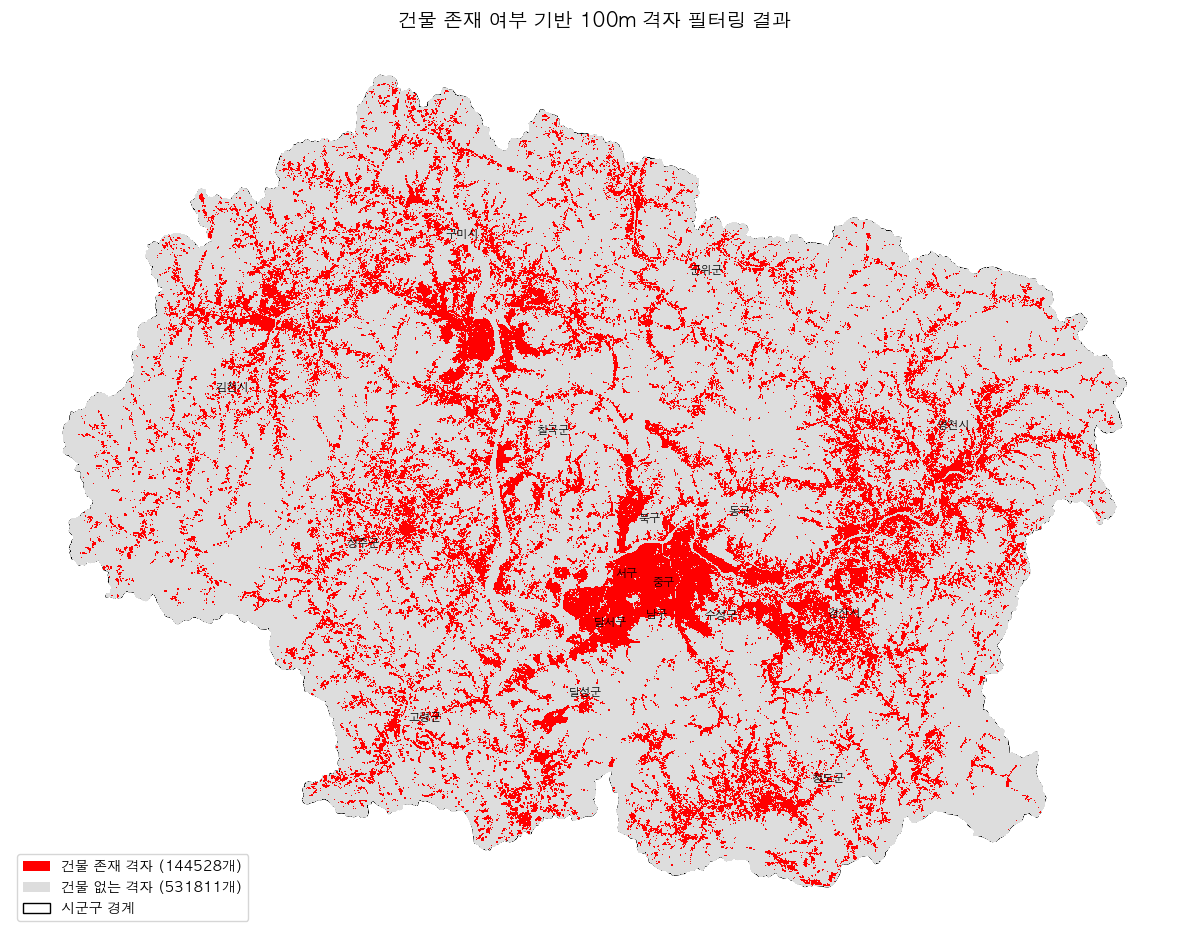

In [7]:
fig, ax = plt.subplots(figsize=(12, 12))

target_sigungu_5179 = target_sigungu.to_crs(grid.crs)

target_sigungu_5179.boundary.plot(ax=ax, color="black", linewidth=1.0, zorder=1)
grid.plot(ax=ax, color="#dddddd", zorder=2)
grid_with_buildings.plot(ax=ax, color="red", zorder=3)

for _, row in target_sigungu_5179.iterrows():
    c = row.geometry.centroid
    ax.annotate(row["SIGUNGU_NM"], xy=(c.x, c.y), ha="center", va="center",
                fontsize=8, fontweight="bold", zorder=4)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="red", label=f"건물 존재 격자 ({len(grid_with_buildings)}개)"),
    Patch(facecolor="#dddddd", label=f"건물 없는 격자 ({len(grid) - len(grid_with_buildings)}개)"),
    Patch(facecolor="none", edgecolor="black", label="시군구 경계"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=10)

ax.set_title("건물 존재 여부 기반 100m 격자 필터링 결과", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{out_dir}/grid_with_buildings_visualization.png", dpi=200)
plt.show()